# Обработка данных обучающего датасета

Импортируем библиотеки и загружаем данные

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

data = pd.read_csv('train_data/loan_data.csv')
df = pd.DataFrame(data)
df.head(5)

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,45000.0,27.764178,6.045108,20.00,24.00,26.00,30.00,144.00
person_income,45000.0,80319.053222,80422.498632,8000.00,47204.00,67048.00,95789.25,7200766.00
person_emp_exp,45000.0,5.410333,6.063532,0.00,1.00,4.00,8.00,125.00
loan_amnt,45000.0,9583.157556,6314.886691,500.00,5000.00,8000.00,12237.25,35000.00
loan_int_rate,45000.0,11.006606,2.978808,5.42,8.59,11.01,12.99,20.00
loan_percent_income,45000.0,0.139725,0.087212,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,45000.0,5.867489,3.879702,2.00,3.00,4.00,8.00,30.00
credit_score,45000.0,632.608756,50.435865,390.00,601.00,640.00,670.00,850.00
loan_status,45000.0,0.222222,0.415744,0.00,0.00,0.00,0.00,1.00


In [4]:
df.isna().sum()

,0
person_age,0
person_gender,0
person_education,0
person_income,0
person_emp_exp,0
person_home_ownership,0
loan_amnt,0
loan_intent,0
loan_int_rate,0
loan_percent_income,0


Пустых ячеек нет


In [5]:
df["loan_status"].value_counts()

df["loan_status"].value_counts(normalize=True)

,proportion
loan_status,
0,0.777778
1,0.222222


Умеренных дисбаланс

Заметим, что есть невозможные значения: возраст 144 года, стаж работы 125 лет

In [6]:
df = df[df["person_age"] <= 100]
df = df[df["person_emp_exp"] <= df["person_age"] - 14]

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
person_age,44993.0,27.748428,5.909737,20.00,24.00,26.00,30.00,94.00
person_income,44993.0,79908.447581,63322.132349,8000.00,47195.00,67046.00,95778.00,2448661.00
person_emp_exp,44993.0,5.394528,5.927159,0.00,1.00,4.00,8.00,76.00
loan_amnt,44993.0,9583.176761,6314.802655,500.00,5000.00,8000.00,12237.00,35000.00
loan_int_rate,44993.0,11.006448,2.978985,5.42,8.59,11.01,12.99,20.00
loan_percent_income,44993.0,0.139736,0.087207,0.00,0.07,0.12,0.19,0.66
cb_person_cred_hist_length,44993.0,5.866557,3.877167,2.00,3.00,4.00,8.00,30.00
credit_score,44993.0,632.585713,50.402411,390.00,601.00,640.00,670.00,784.00
loan_status,44993.0,0.222257,0.415767,0.00,0.00,0.00,0.00,1.00


Для всех числовых признаков посмотрим распредления

In [8]:
numeric_features = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score"
]

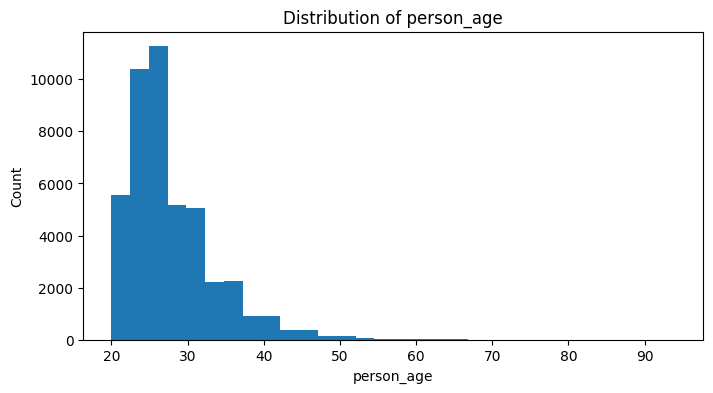

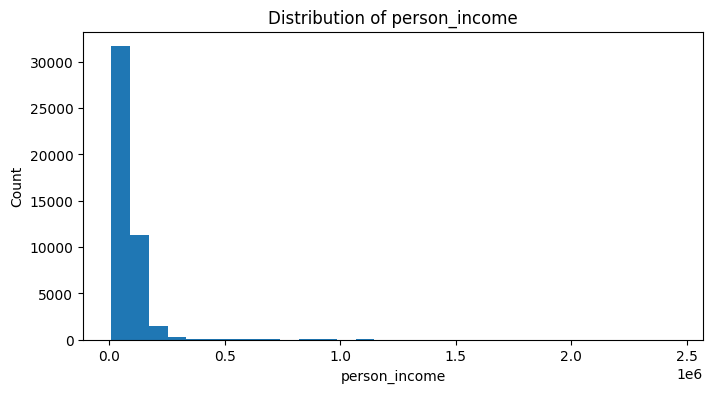

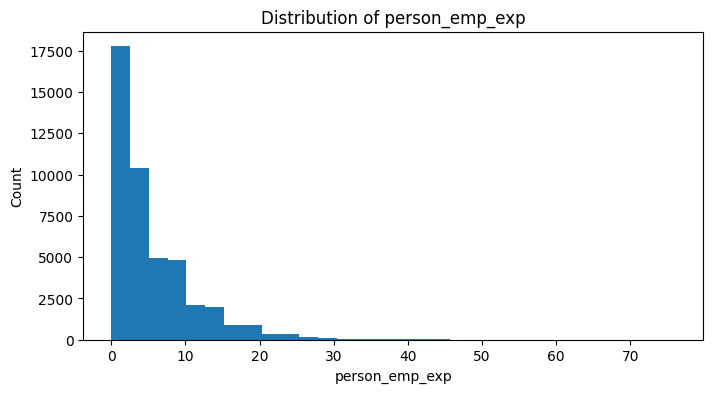

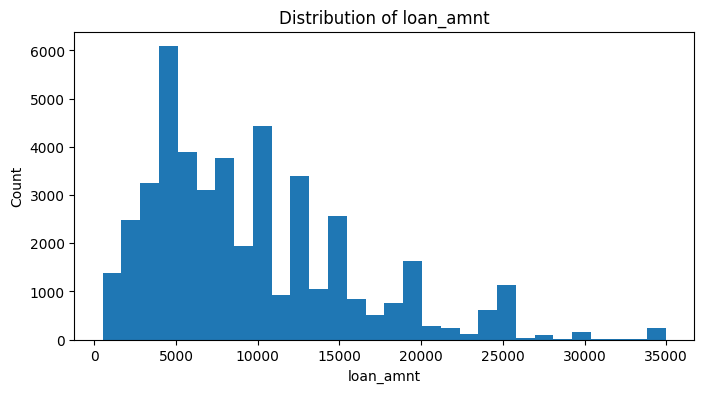

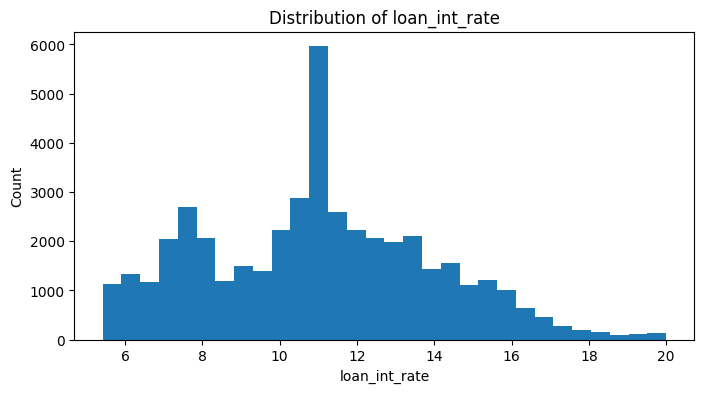

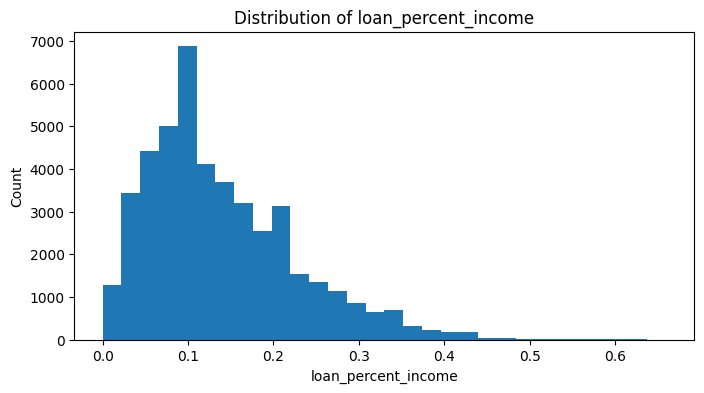

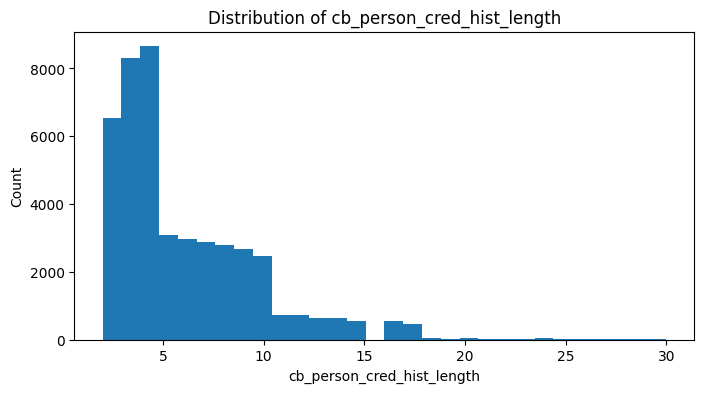

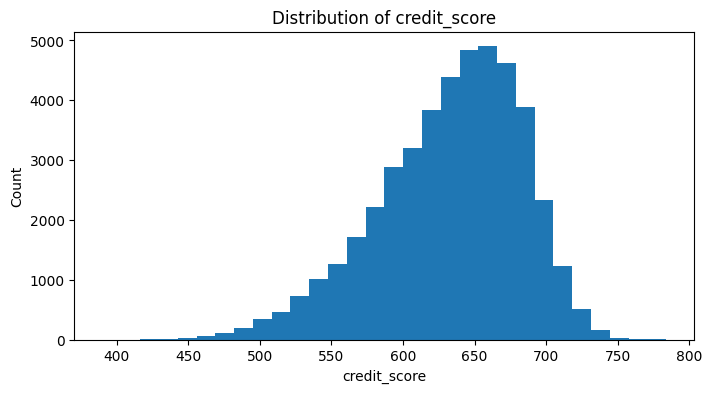

In [9]:

for column in numeric_features:
    plt.figure(figsize=(8, 4))

    plt.hist(
        df[column],
        bins=30
    )

    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Count")

    plt.show()

Boxplot для поиска выбросов

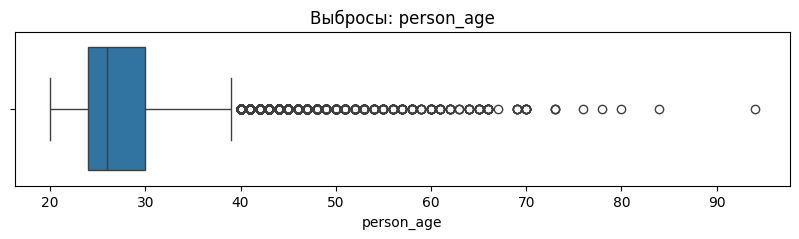

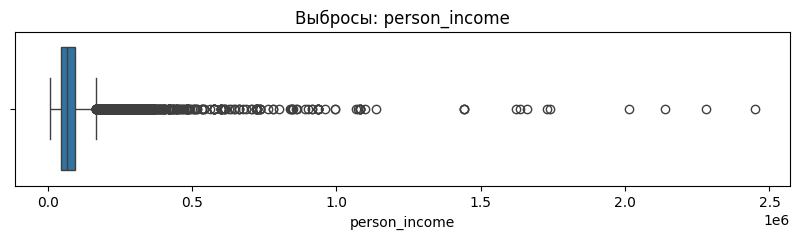

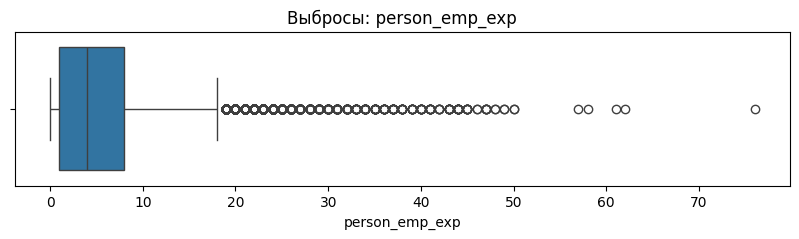

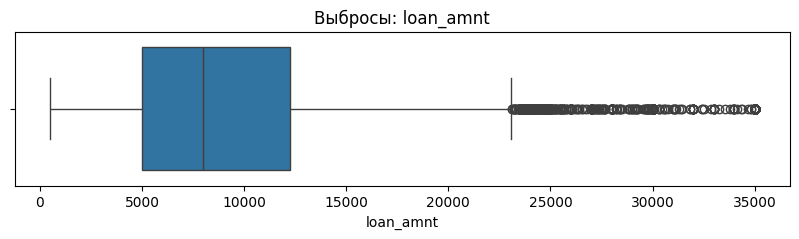

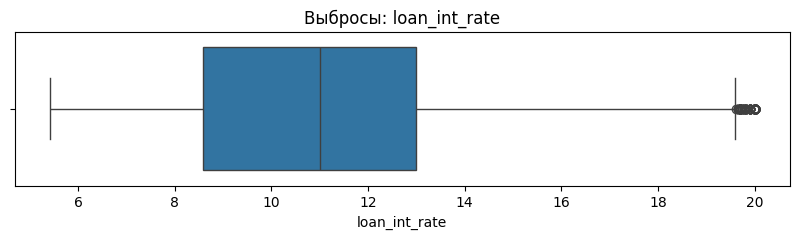

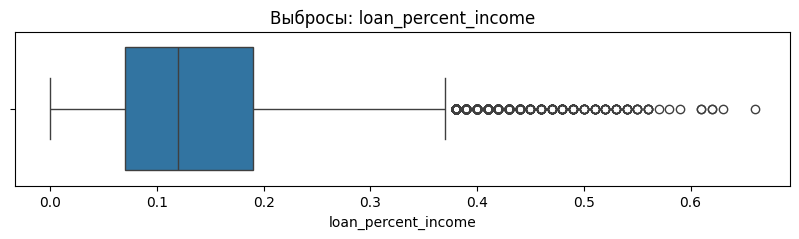

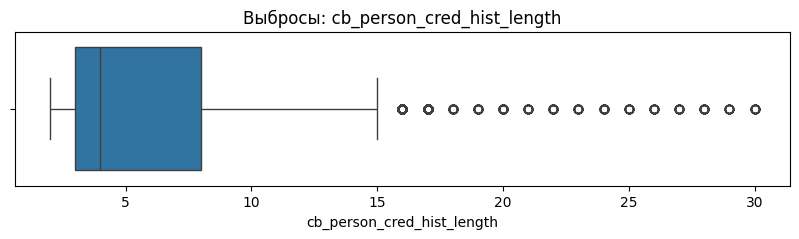

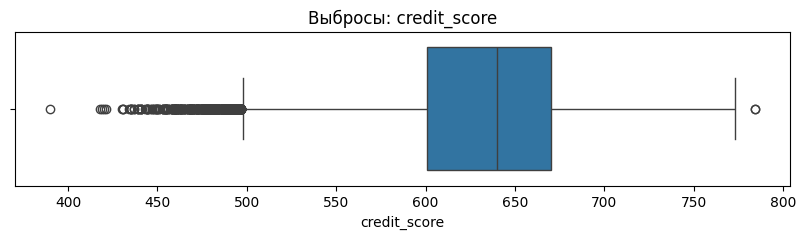

In [10]:
for column in numeric_features:

    plt.figure(figsize=(10,2))

    sns.boxplot(
        x=df[column]
    )

    plt.title(
        f"Выбросы: {column}"
    )

    plt.show()

Доход имеет сильную ассиметрию

In [11]:
df["person_income"] = np.log1p(
    df["person_income"]
)

После логарифмирования

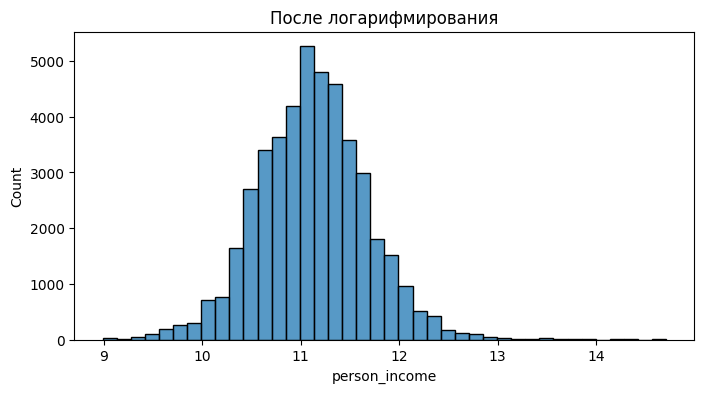

In [12]:
plt.figure(figsize=(8,4))

sns.histplot(
    df["person_income"],
    bins=40
)

plt.title("После логарифмирования")

plt.show()

Для категориальных признаков используем One-hot-encoding

In [13]:
categorical_features = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
]

df = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True
)

In [14]:
df['previous_loan_defaults_on_file'] = df['previous_loan_defaults_on_file'].map({'Yes': 1, 'No': 0})

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 44993 entries, 0 to 44999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      44993 non-null  float64
 1   person_income                   44993 non-null  float64
 2   person_emp_exp                  44993 non-null  int64  
 3   loan_amnt                       44993 non-null  float64
 4   loan_int_rate                   44993 non-null  float64
 5   loan_percent_income             44993 non-null  float64
 6   cb_person_cred_hist_length      44993 non-null  float64
 7   credit_score                    44993 non-null  int64  
 8   previous_loan_defaults_on_file  44993 non-null  int64  
 9   loan_status                     44993 non-null  int64  
 10  person_gender_male              44993 non-null  bool   
 11  person_education_Bachelor       44993 non-null  bool   
 12  person_education_Doctorate      44993

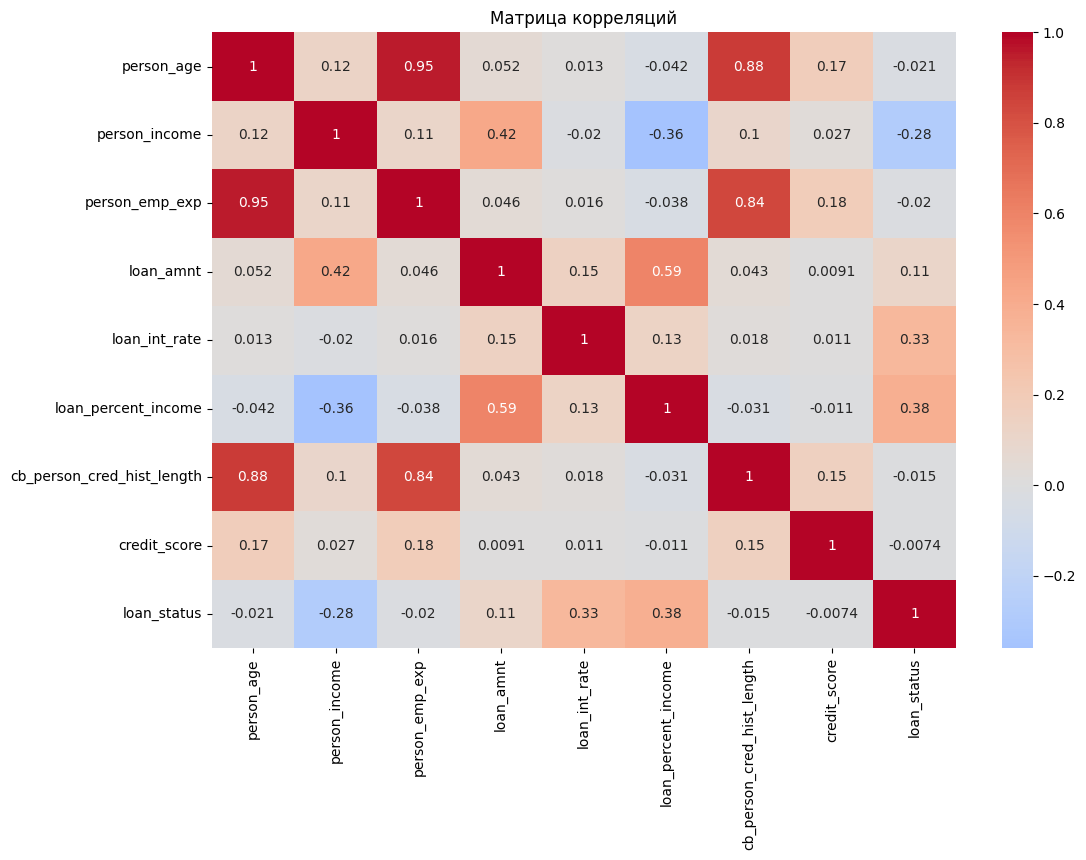

In [16]:
corr_matrix = (
    df[numeric_features + ["loan_status"]]
    .corr()
)

plt.figure(figsize=(12,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title(
    "Матрица корреляций"
)

plt.show()

Возраст коррелирует со стажем работы слишком сильно - 0.95. Стаж работы более важен для того чтобы дать кредит, уберём возраст

In [17]:
df.drop(
    columns=[
        "person_age"
    ],
    inplace=True
)

Признаки с низкой корреляцией не удаляем, поскольку для ансамблевых моделей деревьев решений они могут сохранять прогностическую ценность

Масштабируем числовые признаки

In [18]:
scaler = StandardScaler()

numeric_features.remove("person_age")
df[numeric_features] = scaler.fit_transform(
  df[numeric_features]
)

In [19]:
df.to_csv("new_loan_data.csv", index=False)